# Deep Learning Assignment 2

In [1]:
from pathlib import Path
import h5py
import numpy as np

from scipy.signal import resample

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import sys
import os

# Add src to path for preprocessing module
sys.path.append(str(Path('..').resolve()))
from src.preprocessing import min_max_normalize, z_score_normalize, preprocess_matrix, downsample_matrix

In [2]:
data_root = Path('..') / 'data' / 'raw' / 'Final Project data'
h5_files = sorted(data_root.rglob('*.h5'))

if not h5_files:
    raise FileNotFoundError(f'No .h5 files found under {data_root}')

def get_dataset_name(file_name_with_dir: Path) -> str:
    file_name_without_dir = file_name_with_dir.as_posix().split('/')[-1]
    temp = file_name_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

filename_path = h5_files[0]
print(f'Loading: {filename_path}')

with h5py.File(filename_path, 'r') as f:
    dataset_name = get_dataset_name(filename_path)
    obj = f.get(dataset_name)
    if obj is None:
        raise ValueError(f"Dataset '{dataset_name}' not found in {filename_path}")
    if not isinstance(obj, h5py.Dataset):
        raise ValueError(f"Expected h5py.Dataset, got {type(obj)}")
    dataset: h5py.Dataset = obj
    matrix: np.ndarray = dataset[()]
    print(type(matrix))
    print(matrix.shape)

Loading: ..\data\raw\Final Project data\Cross\test1\rest_162935_1.h5
<class 'numpy.ndarray'>
(248, 35624)


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Select a sample file to visualize (using the first file from your h5_files list)
sample_file_path = h5_files[0]
sample_dataset_name = get_dataset_name(sample_file_path)

with h5py.File(sample_file_path, 'r') as f:
    obj = f.get(sample_dataset_name)
    if obj is None:
        raise ValueError(f"Dataset '{sample_dataset_name}' not found in {sample_file_path}")
    if not isinstance(obj, h5py.Dataset):
        raise TypeError(f"Expected h5py.Dataset, got {type(obj)}")
    raw_matrix = obj[()]

preprocessed_matrix = preprocess_matrix(raw_matrix)

target_downsample_rate = 200
downsampled_matrix = downsample_matrix(preprocessed_matrix, downsample_rate=target_downsample_rate)

downsample_factor = preprocessed_matrix.shape[1] / downsampled_matrix.shape[1]

print(f"Data Shapes")
print(f"Original/Preprocessed Matrix Shape: {preprocessed_matrix.shape} (Channels, Time Steps)")
print(f"Downsampled Matrix Shape:           {downsampled_matrix.shape} (Channels, Time Steps)")
print(f"Downsampling Factor:                {downsample_factor:.2f}x fewer time points")

Data Shapes
Original/Preprocessed Matrix Shape: (248, 35624) (Channels, Time Steps)
Downsampled Matrix Shape:           (248, 3563) (Channels, Time Steps)
Downsampling Factor:                10.00x fewer time points


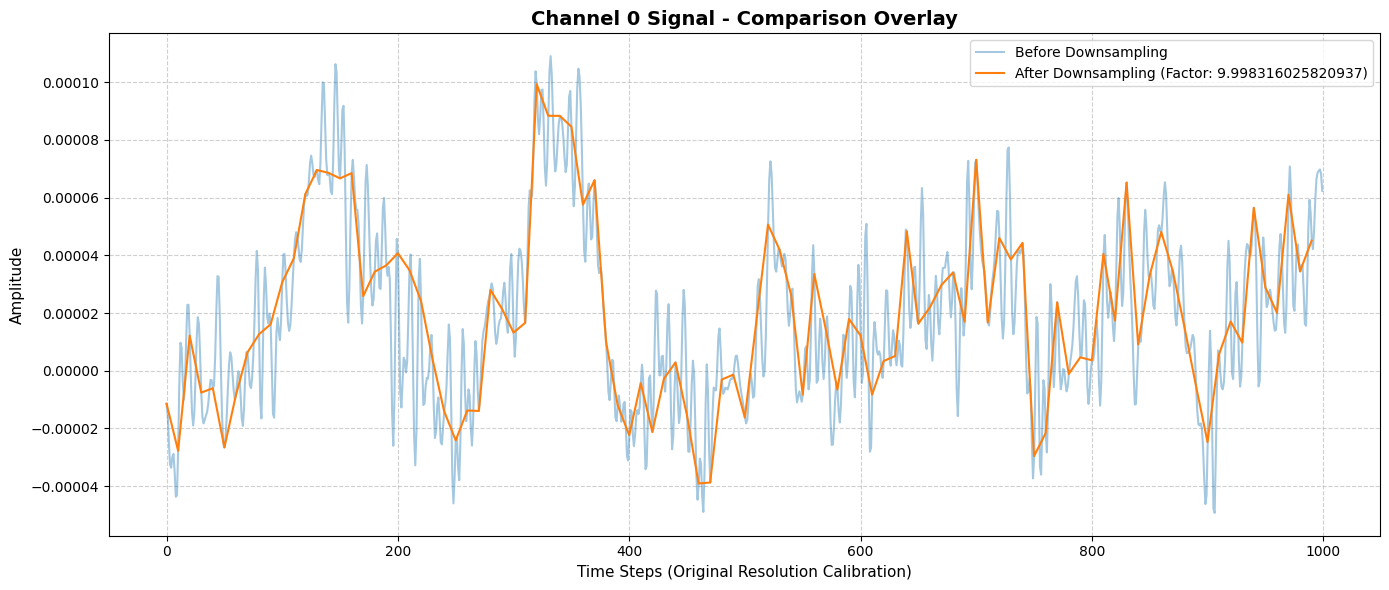

In [4]:
import numpy as np
import matplotlib.pyplot as plt

channel_to_visualize = 0
raw_time_window_length = 1000

time_window_raw = slice(0, raw_time_window_length)
time_window_ds = slice(0, int(raw_time_window_length / downsample_factor))

x_raw = np.arange(0, raw_time_window_length)
x_ds = np.arange(0, int(raw_time_window_length / downsample_factor)) * downsample_factor

plt.figure(figsize=(14, 6))

plt.plot(x_raw, preprocessed_matrix[channel_to_visualize, time_window_raw], 
         label='Before Downsampling', color='#1f77b4', alpha=0.4, linewidth=1.5)

plt.plot(x_ds, downsampled_matrix[channel_to_visualize, time_window_ds], 
         label=f'After Downsampling (Factor: {downsample_factor})', 
         color='#ff7f0e', alpha=1, linewidth=1.5, linestyle='-')

plt.title(f'Channel {channel_to_visualize} Signal - Comparison Overlay', fontsize=14, fontweight='bold')
plt.xlabel('Time Steps (Original Resolution Calibration)', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('meg_signal_overlay_comparison.png', dpi=300)
plt.show()

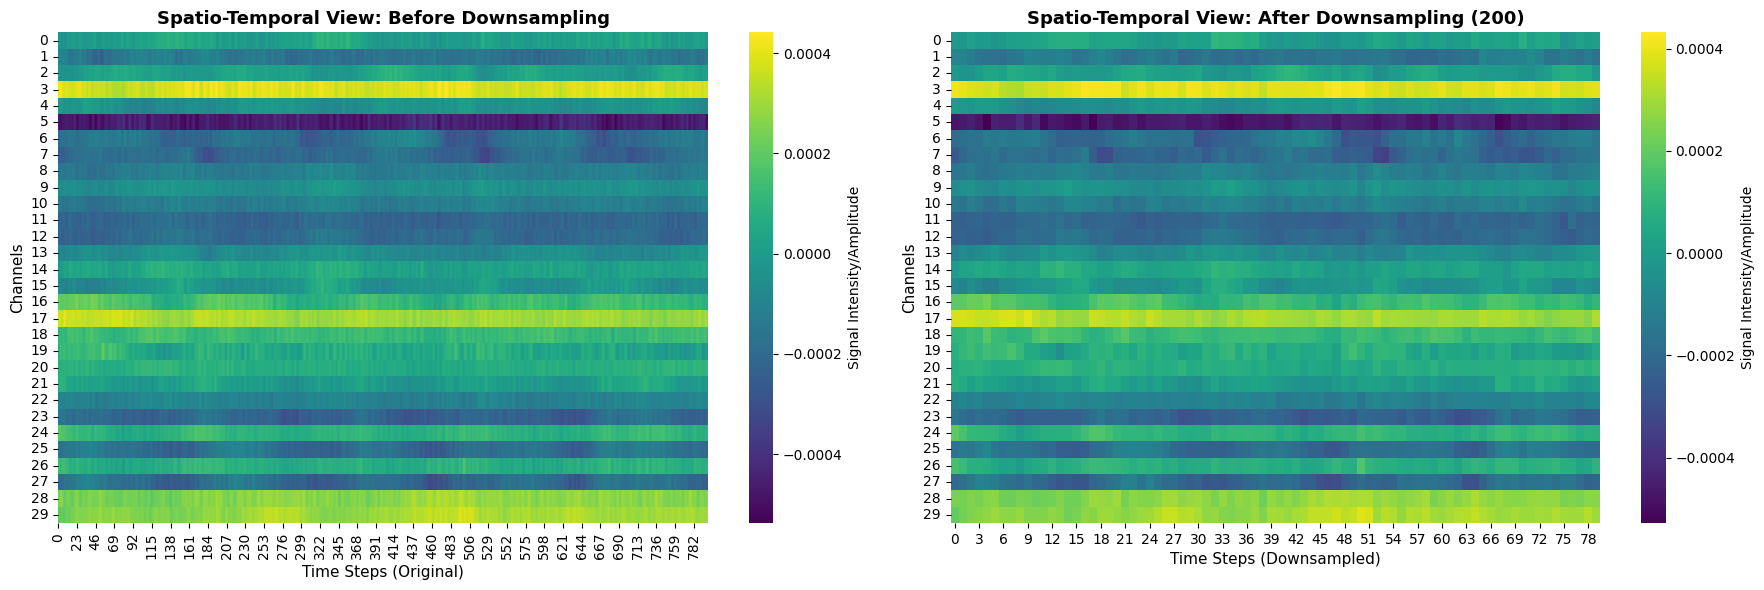

In [5]:
# --- Configuration ---
num_channels_to_plot = 30       # Number of channels to display on the y-axis
raw_heatmap_time_length = 800   # Number of time steps for the original heatmap

# Define matching time windows for alignment
heatmap_time_raw = preprocessed_matrix[:num_channels_to_plot, :raw_heatmap_time_length]
heatmap_time_ds = downsampled_matrix[:num_channels_to_plot, :int(raw_heatmap_time_length / downsample_factor)]

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1. Heatmap Before Downsampling
sns.heatmap(heatmap_time_raw, cmap='viridis', ax=ax1, 
            cbar_kws={'label': 'Signal Intensity/Amplitude'})
ax1.set_title('Spatio-Temporal View: Before Downsampling', fontsize=13, fontweight='bold')
ax1.set_xlabel('Time Steps (Original)', fontsize=11)
ax1.set_ylabel('Channels', fontsize=11)

# 2. Heatmap After Downsampling
sns.heatmap(heatmap_time_ds, cmap='viridis', ax=ax2, 
            cbar_kws={'label': 'Signal Intensity/Amplitude'})
ax2.set_title(f'Spatio-Temporal View: After Downsampling ({target_downsample_rate})', fontsize=13, fontweight='bold')
ax2.set_xlabel('Time Steps (Downsampled)', fontsize=11)
ax2.set_ylabel('Channels', fontsize=11)

plt.tight_layout()
plt.savefig('meg_heatmap_comparison.png', dpi=300)
plt.show()

In [6]:
from torch_geometric.data import Data, Dataset as PyGDataset

label_map = {
    "rest": 0,
    "task_motor": 1,
    "task_story_math": 2,
    "task_working_memory": 3
}

def fully_connected_edge_list(nodes = 248):
    rows, cols = [], []

    for i in range(nodes):
        for j in range(nodes):
            if (i != j):
                rows.append(i)
                cols.append(j)

    return torch.tensor([rows, cols], dtype = torch.long)

def k_nearest_neighbor_edge_list(k = 8, nodes = 248):
    rows, cols = [], []

    for i in range(nodes):
        for j in range(max(0, i-k), min(nodes, i + k + 1)):
            if i != j:
                rows.append(i)
                cols.append(j)

    return torch.tensor([rows, cols], dtype = torch.long)

edge_list = fully_connected_edge_list()

# Very similar to MEGDataset but has extra edge list for the Graph Attention Network
class MEGGraphDataset(PyGDataset):
    def __init__(self, file_paths, persist_dir = None, downsample_rate = 250):
        super().__init__(root=None)  # required for PyG Dataset
        self.file_paths = file_paths
        self.persist_dir = persist_dir
        self.downsample_rate = downsample_rate

    def len(self):
        return len(self.file_paths)
    
    def get(self, idx):
        file_path = self.file_paths[idx]
        filename = file_path.name

        # map label from filename
        label_str = next((k for k in label_map.keys() if filename.startswith(k)), None)
        if label_str is None:
            raise ValueError(f"Unknown label in filename: {filename}")

        label = label_map[label_str]

        if self.persist_dir:
            save_path = Path(self.persist_dir) / f"{filename}.npy"
            if save_path.exists():
                matrix = np.load(save_path)
                return Data(x = torch.tensor(matrix, dtype = torch.float32), edge_index = edge_list, y = torch.tensor(label, dtype = torch.long))
            
        with h5py.File(file_path, 'r') as f:
            dataset_name = "_".join(filename.split('_')[:-1])
            obj = f.get(dataset_name)

            if obj is None:
                raise ValueError(f"Dataset '{dataset_name}' not found in {file_path}")
            if not isinstance(obj, h5py.Dataset):
                raise TypeError(f"Expected h5py.Dataset, got {type(obj)}")
            matrix = obj[()]

            matrix = preprocess_matrix(matrix)
            matrix = downsample_matrix(matrix, downsample_rate = self.downsample_rate)

            if self.persist_dir:
                np.save(save_path, matrix)

            return Data(x = torch.tensor(matrix, dtype = torch.float32), edge_index = edge_list, y = torch.tensor(label, dtype = torch.long))

c:\Users\Marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
from torch_geometric.loader import DataLoader as PyGDataLoader

data_root = Path('..') / 'data' / 'raw' / 'Final Project data'
processed_dir = Path('..') / 'data' / 'processed'

intra_train_files = list((data_root / 'Intra' / 'train').rglob('*.h5'))
intra_test_files = list((data_root / 'Intra' / 'test').rglob('*.h5'))

intra_train_graph_dataset = MEGGraphDataset(intra_train_files, persist_dir = processed_dir)
intra_test_graph_dataset = MEGGraphDataset(intra_test_files, persist_dir = processed_dir)

batch_size = 4
intra_train_graph_loader = PyGDataLoader(intra_train_graph_dataset, batch_size = batch_size, shuffle = True)
intra_test_graph_loader = PyGDataLoader(intra_test_graph_dataset, batch_size = batch_size, shuffle = False)

print(f"intra: {len(intra_train_graph_dataset)} train, {len(intra_test_graph_dataset)} test")

intra: 32 train, 8 test


In [8]:
cross_train_files = list((data_root / 'Cross' / 'train').rglob('*.h5'))
cross_test_files = []
for i in [1, 2, 3]:
    cross_test_files.extend((data_root / 'Cross' / f'test{i}').rglob('*.h5'))

cross_train_graph_dataset = MEGGraphDataset(cross_train_files, persist_dir = processed_dir)
cross_test_graph_dataset = MEGGraphDataset(cross_test_files, persist_dir = processed_dir)

cross_train_graph_loader = PyGDataLoader(cross_train_graph_dataset, batch_size = batch_size, shuffle = True)
cross_test_graph_loader = PyGDataLoader(cross_test_graph_dataset, batch_size = batch_size, shuffle = False)

print(f"cross: {len(cross_train_graph_dataset)} train, {len(cross_test_graph_dataset)} test")

cross: 64 train, 48 test


In [ ]:
from torch_geometric.nn import GATConv, global_max_pool

class GAT_GRU_Classifier(nn.Module):
    def __init__(self, num_classes = 4, hidden_dim = 32, heads = 2, dropout = 0.5, gru_hidden = 64, pool_size = 64):
        super().__init__()

        self.leaky_relu = nn.LeakyReLU(0.01)
        self.pool_size = pool_size

        # reduces temporal dimension to pool_size
        self.temporal_pool = nn.AdaptiveAvgPool1d(pool_size)
        # normlaize to prevent activations from becoming meaningless in GAT
        self.input_norm = nn.BatchNorm1d(pool_size)

        # GAT for spatial graph attention
        # output size: hidden_dim * heads for each time step
        self.gat1 = GATConv(
            in_channels = 1,
            out_channels = hidden_dim,
            heads = heads,
            dropout = dropout,
            concat = False # For attention
        )

        # Pooling applied inbetween to reduce parameters

        # GRU to process temporal sequence
        self.gru = nn.GRU(
            input_size = hidden_dim, 
            hidden_size = gru_hidden, 
            num_layers = 1, 
            batch_first = True
        )

        # classifier head
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(gru_hidden, 32),
            nn.LeakyReLU(0.01),
            nn.Linear(32, num_classes)
        )

    def forward(self, x, edge_list, batch):
        batch_size = batch.max().item() + 1

        # pool time dimension, reduce to only 64 "timesteps"
        x = self.temporal_pool(x.unsqueeze(1)).squeeze(1)
        x = self.input_norm(x)

        # GAT for each timestep
        graph_sequence = []
        for t in range(self.pool_size):
            x_t = x[:, t].unsqueeze(1)
            x_t = self.leaky_relu(self.gat1(x_t, edge_list))
            x_t = global_max_pool(x_t, batch) # pooling for GAT
            graph_sequence.append(x_t) 

        graph_sequence = torch.stack(graph_sequence, dim=1)

        _, h_n = self.gru(graph_sequence)
        return self.fc(h_n.squeeze(0))

def build_model(input_channels=248):
    return GAT_GRU_Classifier(num_classes = 4, pool_size = 64, dropout = 0.1)

model = build_model()
print(model)

GAT_GRU_Classifier(
  (leaky_relu): LeakyReLU(negative_slope=0.01)
  (temporal_pool): AdaptiveAvgPool1d(output_size=64)
  (input_norm): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat1): GATConv(1, 32, heads=2)
  (gru): GRU(32, 64, batch_first=True)
  (fc): Sequential(
    (0): Dropout(p=0.1, inplace=False)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=32, out_features=4, bias=True)
  )
)


In [10]:
import copy

def train_gat_gru_model(model, train_loader, test_loader, num_epochs = 100, learning_rate = 3e-3, patience = 25):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate, weight_decay = 1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', patience = 5, factor = 0.5)
    
    results = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
    
    best_test_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            outputs = model(batch.x, batch.edge_index, batch.batch)
            loss = criterion(outputs, batch.y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * batch.num_graphs
            _, predicted = torch.max(outputs, 1)
            total += batch.num_graphs
            correct += (predicted == batch.y).sum().item()

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        model.eval()
        test_loss_sum, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(device)
                outputs = model(batch.x, batch.edge_index, batch.batch)
                loss = criterion(outputs, batch.y)
                test_loss_sum += loss.item() * batch.num_graphs
                _, predicted = torch.max(outputs, 1)
                test_total += batch.num_graphs
                test_correct += (predicted == batch.y).sum().item()
        
        test_loss = test_loss_sum / test_total if test_total > 0 else 0
        test_acc = test_correct / test_total if test_total > 0 else 0

        print(f"Epoch {epoch+1:02d}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f} - Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.4f}")
        
        results['train_loss'].append(epoch_loss)
        results['train_acc'].append(epoch_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)

        scheduler.step(test_loss)
        
        # Early Stopping based on validation loss
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
                
    # Load the best model weights
    model.load_state_dict(best_model_wts)
    return results

print("training cnn-gat on intra-subject split...")
gat_gru_intra_model = build_model()
gat_gru_intra_results = train_gat_gru_model(gat_gru_intra_model, intra_train_graph_loader, intra_test_graph_loader)

training cnn-gat on intra-subject split...
Epoch 01/100 - Train Loss: 1.3982 - Train Acc: 0.2500 - Test Loss: 1.3895 - Test Acc: 0.2500
Epoch 02/100 - Train Loss: 1.3886 - Train Acc: 0.2500 - Test Loss: 1.3891 - Test Acc: 0.2500
Epoch 03/100 - Train Loss: 1.3706 - Train Acc: 0.2812 - Test Loss: 1.3878 - Test Acc: 0.2500
Epoch 04/100 - Train Loss: 1.2972 - Train Acc: 0.4688 - Test Loss: 1.3889 - Test Acc: 0.2500
Epoch 05/100 - Train Loss: 1.3071 - Train Acc: 0.5000 - Test Loss: 1.4406 - Test Acc: 0.2500
Epoch 06/100 - Train Loss: 1.0645 - Train Acc: 0.5625 - Test Loss: 2.0071 - Test Acc: 0.2500
Epoch 07/100 - Train Loss: 0.9490 - Train Acc: 0.4375 - Test Loss: 1.9237 - Test Acc: 0.2500
Epoch 08/100 - Train Loss: 0.9993 - Train Acc: 0.4375 - Test Loss: 2.4902 - Test Acc: 0.2500
Epoch 09/100 - Train Loss: 0.8302 - Train Acc: 0.5312 - Test Loss: 2.0944 - Test Acc: 0.2500
Epoch 10/100 - Train Loss: 0.8412 - Train Acc: 0.5625 - Test Loss: 2.0537 - Test Acc: 0.2500
Epoch 11/100 - Train Loss: 

In [11]:
print("training cnn-gat on cross-subject split...")
gat_gru_cross_model = build_model()
gat_gru_cross_results = train_gat_gru_model(gat_gru_cross_model, cross_train_graph_loader, cross_test_graph_loader)

training cnn-gat on cross-subject split...
Epoch 01/100 - Train Loss: 1.3979 - Train Acc: 0.2344 - Test Loss: 1.3896 - Test Acc: 0.2500
Epoch 02/100 - Train Loss: 1.3821 - Train Acc: 0.2812 - Test Loss: 1.3867 - Test Acc: 0.2500
Epoch 03/100 - Train Loss: 1.1639 - Train Acc: 0.3906 - Test Loss: 1.8945 - Test Acc: 0.2500
Epoch 04/100 - Train Loss: 0.9508 - Train Acc: 0.3906 - Test Loss: 2.6579 - Test Acc: 0.2500
Epoch 05/100 - Train Loss: 0.8632 - Train Acc: 0.4844 - Test Loss: 1.9712 - Test Acc: 0.2292
Epoch 06/100 - Train Loss: 0.8219 - Train Acc: 0.4688 - Test Loss: 2.3695 - Test Acc: 0.3750
Epoch 07/100 - Train Loss: 0.7419 - Train Acc: 0.6094 - Test Loss: 1.5928 - Test Acc: 0.4583
Epoch 08/100 - Train Loss: 0.7963 - Train Acc: 0.5469 - Test Loss: 1.5042 - Test Acc: 0.3750
Epoch 09/100 - Train Loss: 0.7578 - Train Acc: 0.6094 - Test Loss: 1.5526 - Test Acc: 0.3958
Epoch 10/100 - Train Loss: 0.7469 - Train Acc: 0.5625 - Test Loss: 1.5521 - Test Acc: 0.3542
Epoch 11/100 - Train Loss: 

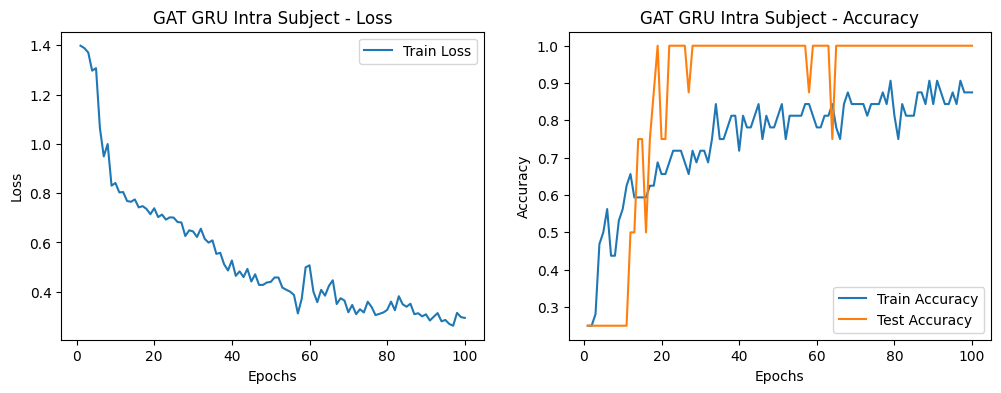

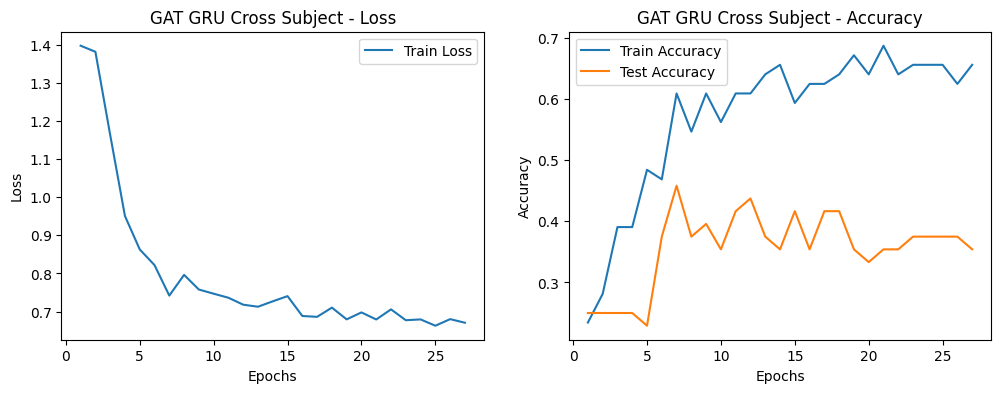

GAT Test Acc: 1.0000
GAT Test Acc: 0.3542
Gap: 0.6458


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_learning_curves(results_dict, title):
    epochs = range(1, len(results_dict['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, results_dict['train_loss'], label='Train Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax2.plot(epochs, results_dict['train_acc'], label='Train Accuracy')
    ax2.plot(epochs, results_dict['test_acc'], label='Test Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    Path('../reports/figures').mkdir(parents=True, exist_ok=True)
    plt.savefig(f"../reports/figures/{title.replace(' ', '_')}.png")
    plt.show()

plot_learning_curves(gat_gru_intra_results, 'GAT GRU Intra Subject')
plot_learning_curves(gat_gru_cross_results, 'GAT GRU Cross Subject')


print(f"GAT Test Acc: {gat_gru_intra_results['test_acc'][-1]:.4f}")
print(f"GAT Test Acc: {gat_gru_cross_results['test_acc'][-1]:.4f}")
print(f"Gap: {gat_gru_intra_results['test_acc'][-1] - gat_gru_cross_results['test_acc'][-1]:.4f}")

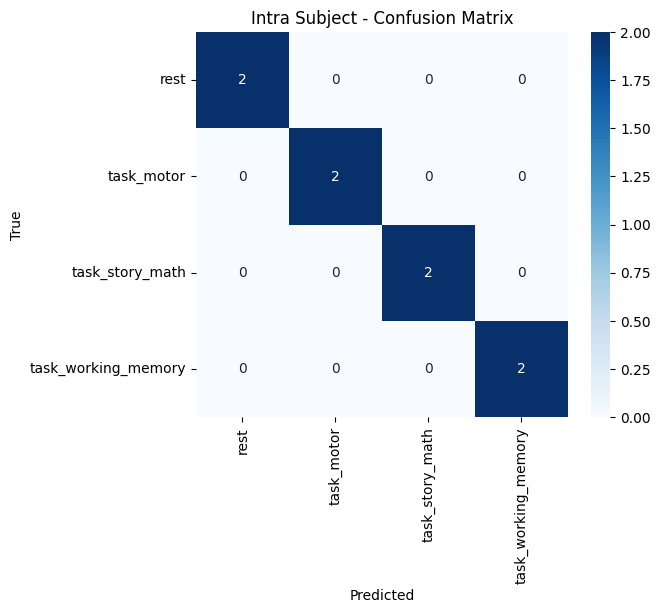

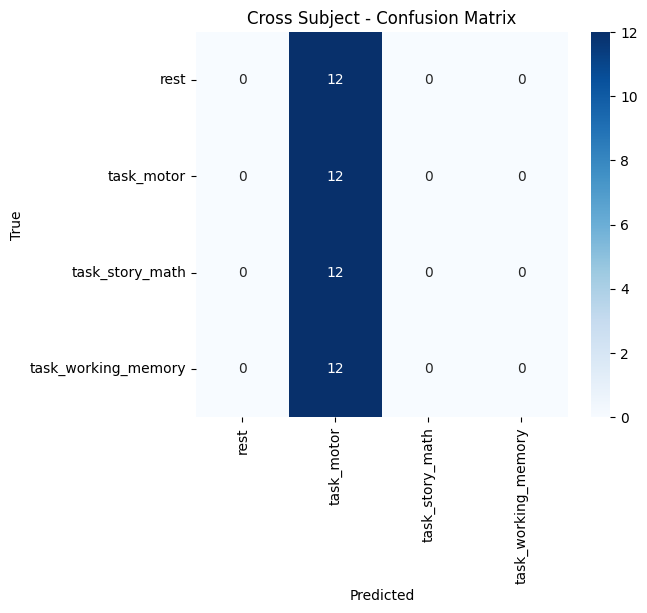

In [13]:
def plot_confusion_matrix(model, test_loader, title):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            outputs = model(batch.x, batch.edge_index, batch.batch)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=list(label_map.keys()), 
                yticklabels=list(label_map.keys()))
    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    
    plt.savefig(f"../reports/figures/cm_{title.replace(' ', '_')}.png")
    plt.show()

plot_confusion_matrix(gat_gru_intra_model, intra_test_graph_loader, 'Intra Subject')
plot_confusion_matrix(gat_gru_cross_model, cross_test_graph_loader, 'Cross Subject')

testing different learning rates

--- LR: 0.001 ---
Epoch 01/100 - Train Loss: 1.4000 - Train Acc: 0.2500 - Test Loss: 1.3970 - Test Acc: 0.2500
Epoch 02/100 - Train Loss: 1.3956 - Train Acc: 0.2500 - Test Loss: 1.3960 - Test Acc: 0.2500
Epoch 03/100 - Train Loss: 1.3969 - Train Acc: 0.2500 - Test Loss: 1.3939 - Test Acc: 0.2500
Epoch 04/100 - Train Loss: 1.3932 - Train Acc: 0.2500 - Test Loss: 1.3929 - Test Acc: 0.2500
Epoch 05/100 - Train Loss: 1.3928 - Train Acc: 0.2500 - Test Loss: 1.3919 - Test Acc: 0.2500
Epoch 06/100 - Train Loss: 1.3915 - Train Acc: 0.2500 - Test Loss: 1.3909 - Test Acc: 0.2500
Epoch 07/100 - Train Loss: 1.3913 - Train Acc: 0.2500 - Test Loss: 1.3899 - Test Acc: 0.2500
Epoch 08/100 - Train Loss: 1.3863 - Train Acc: 0.2500 - Test Loss: 1.3895 - Test Acc: 0.2500
Epoch 09/100 - Train Loss: 1.3828 - Train Acc: 0.2500 - Test Loss: 1.3884 - Test Acc: 0.2500
Epoch 10/100 - Train Loss: 1.3607 - Train Acc: 0.3125 - Test Loss: 1.3874 - Test Acc: 0.2500
Epoch 11/100 - Tra

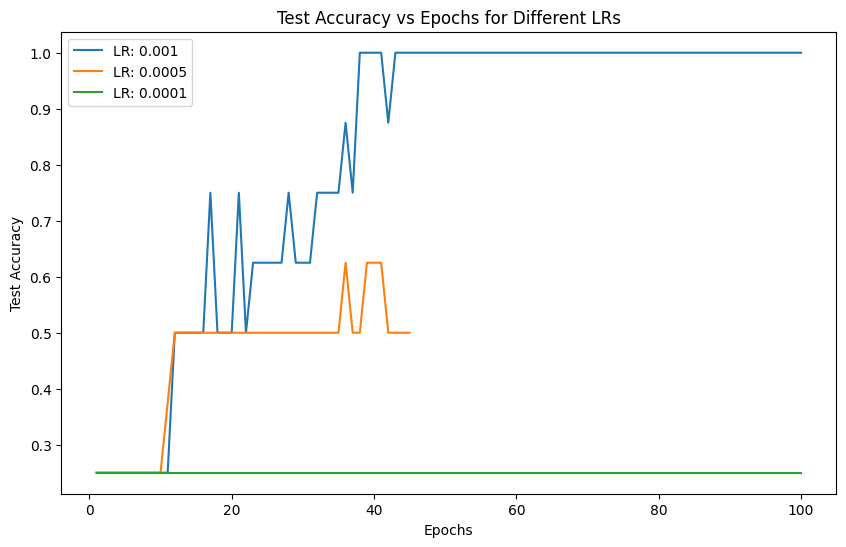

In [14]:
learning_rates = [1e-3, 5e-4, 1e-4]
hyper_results = {}

print("testing different learning rates")
for lr in learning_rates:
    print(f"\n--- LR: {lr} ---")
    hyper_model = build_model()
    res = train_gat_gru_model(hyper_model, intra_train_graph_loader, intra_test_graph_loader, num_epochs=100, patience = 25, learning_rate=lr)
    hyper_results[str(lr)] = res

plt.figure(figsize=(10, 6))
for lr, res in hyper_results.items():
    plt.plot(range(1, len(res['test_acc']) + 1), res['test_acc'], label=f'LR: {lr}')

plt.title('Test Accuracy vs Epochs for Different LRs')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.legend()
plt.savefig("../reports/figures/lr_comparison.png")
plt.show()